In [85]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy as sp
import time
import scipy.stats as stats
from pathlib import Path
import numpy as np




In [86]:
folder = Path('../../data/4_growth_phenotyping/')

res_df = pd.read_csv(folder / 'fitted_growth_parameters.csv', index_col=0)
binary_growth = pd.read_csv(folder/'growth_no_growth.csv', index_col = 0)
binary_growth.index = binary_growth.index.str.replace('L-', '').str.replace('D-','').str.capitalize()
binary_growth_dict = binary_growth.to_dict()

In [87]:
res_df['Carbon source'] = res_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

In [88]:
cs_class_df = pd.read_csv(folder / 'carbon_sources.csv', index_col=0)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Class']

# Make heatmaps

In [89]:
res_df = res_df.loc[res_df['Carbon source'] != 'No cs']

In [96]:
# Get the first four colors from the 'tab10' colormap
tab10_colors = plt.cm.tab10.colors[:4]

# Create a mapping from classes to colors
unique_classes = sorted([x for x in list(set(cs_to_class.values())) if isinstance(x, str)]) # Get unique classes from cs_to_class
class_to_color = {cls: tab10_colors[i] for i, cls in enumerate(unique_classes)}

# Map the classes in `cs_to_class` to colors
row_colors = mu_matrix.index.map(cs_to_class).map(class_to_color)


## Yield

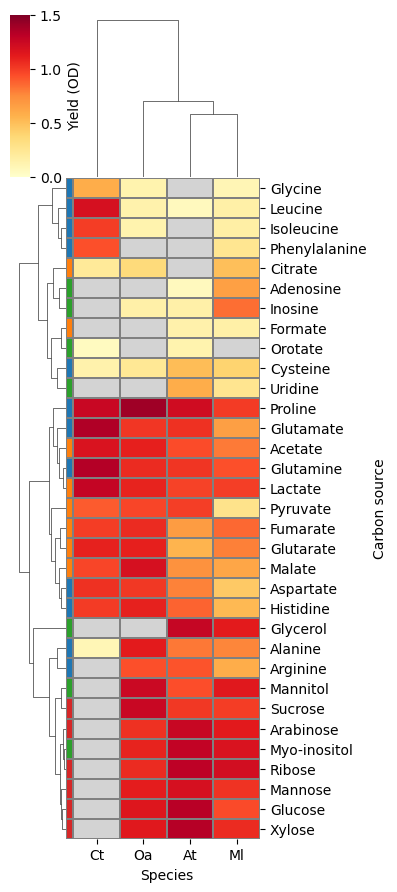

In [97]:
cmap = plt.colormaps.get_cmap('YlOrRd')
cmap.set_bad("lightgray")

yield_matrix = res_df[['Carbon source', 'Yield', 'Species']].pivot(index = 'Carbon source', columns='Species', values='Yield')
mask = np.zeros(yield_matrix.shape, dtype=bool)
for i, c in enumerate(yield_matrix.index):
    for j, s in enumerate(yield_matrix.columns):
        mask[i,j] = not binary_growth_dict[s][c]
sns.clustermap(yield_matrix, vmin = 0, vmax = 1.5, cmap = cmap, mask = mask,figsize=(4,9), dendrogram_ratio=0.2, cbar_kws={'label': 'Yield (OD)'}, 
               row_colors=row_colors,
               linewidths=0.1, linecolor='gray')
fn_fig = '../../Supplementary_figures/clustermap_yield.pdf'
plt.savefig(fn_fig)

In [93]:
species = list(res_df.Species.unique())
species.sort()
carbon_sources = list(res_df['Carbon source'].unique())
carbon_sources.sort()
# carbon_sources.append(carbon_sources.pop(carbon_sources.index('No CS')))
carbon_sources = [x for x in carbon_sources if x != 'No cs']

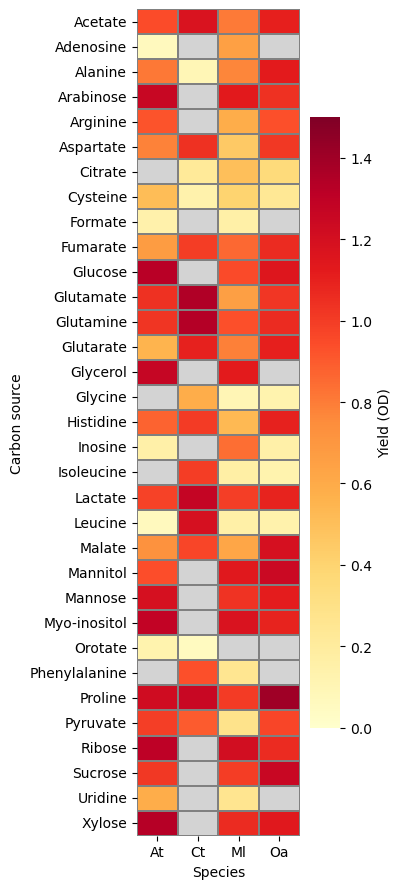

In [99]:
fig, ax = plt.subplots(1, figsize=(4,9))
sns.heatmap(yield_matrix.loc[carbon_sources, species], vmin = 0, vmax = 1.5, 
            cmap = cmap, mask = mask, cbar_kws={'label': 'Yield (OD)'}, ax = ax, linewidths=0.1, linecolor='gray')
plt.tight_layout()
plt.savefig('../../Supplementary_figures/heatmap_yield.pdf')

## Growth rate

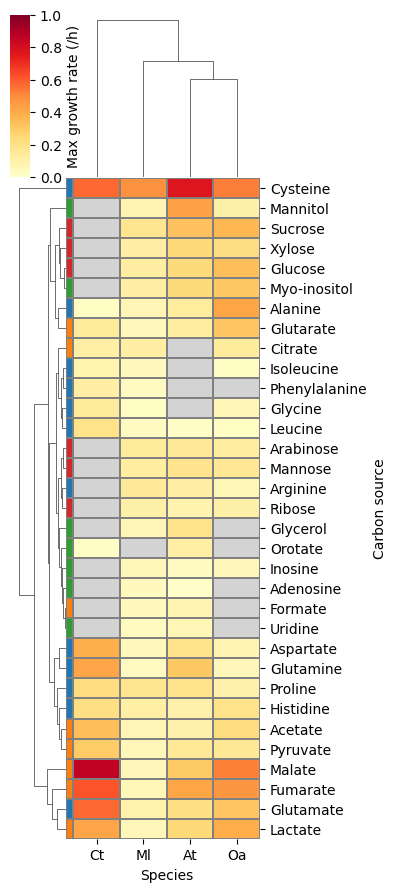

In [100]:
cmap = plt.colormaps.get_cmap('YlOrRd')
cmap.set_bad("lightgray")

mu_matrix = res_df[['Carbon source', 'max_growth_rate', 'Species']].pivot(index = 'Carbon source', columns='Species', values='max_growth_rate')
mask = np.zeros(mu_matrix.shape, dtype=bool)
for i, c in enumerate(mu_matrix.index):
    for j, s in enumerate(mu_matrix.columns):
        mask[i,j] = not binary_growth_dict[s][c]
mu_matrix.fillna(0, inplace=True)
sns.clustermap(mu_matrix, vmin = 0, vmax = 1, cmap = cmap, mask = mask,figsize=(4,9),
                dendrogram_ratio=0.2, cbar_kws={'label': 'Max growth rate (/h)'},
                row_colors=row_colors,
                  linewidths=0.1, linecolor='gray')
plt.savefig('../../Supplementary_figures/clustermap_growth_rate.pdf')

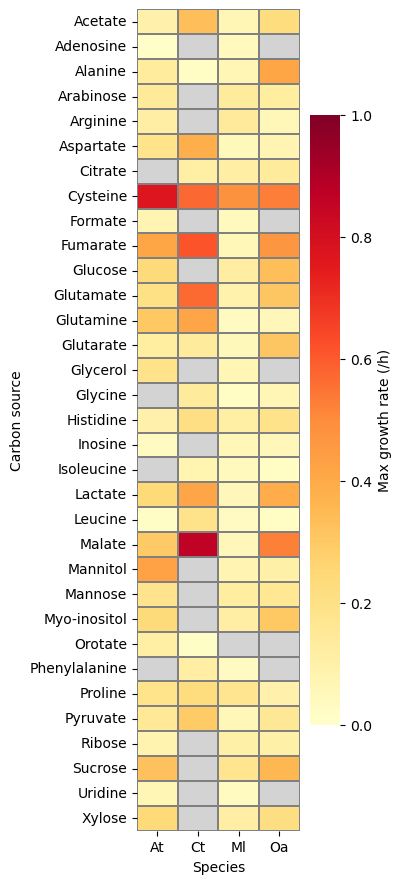

In [ ]:
fig, ax = plt.subplots(1, figsize=(4,9))
sns.heatmap(mu_matrix.loc[carbon_sources, species], vmin = 0, vmax = 1, cmap = cmap, mask = mask, cbar_kws={'label': 'Max growth rate (/h)'}, ax = ax, linewidths=0.1, linecolor='gray')
plt.tight_layout()
plt.savefig('../../Supplementary_figures/heatmap_growth_rate.pdf')

# Plot distributions

In [ ]:
res_df[['Carbon source', 'max_growth_rate', 'Species']]

,Carbon source,max_growth_rate,Species
0,Acetate,0.095601,At
1,Adenosine,0.013572,At
2,Citrate,NaN,At
3,Cysteine,0.769567,At
4,Arabinose,0.144967,At
...,...,...,...
130,Proline,0.095275,Oa
131,Pyruvate,0.156408,Oa
132,Ribose,0.103032,Oa
133,Sucrose,0.356051,Oa


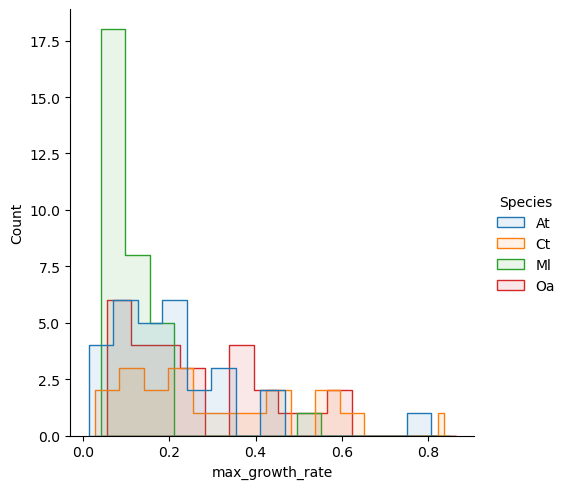

In [ ]:
# mu_matrix
sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = False, multiple="dodge", bins = 15, element="step", fill=True, alpha = 0.1)
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = False, multiple="dodge", bins = 15, element="step", fill=True)

# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


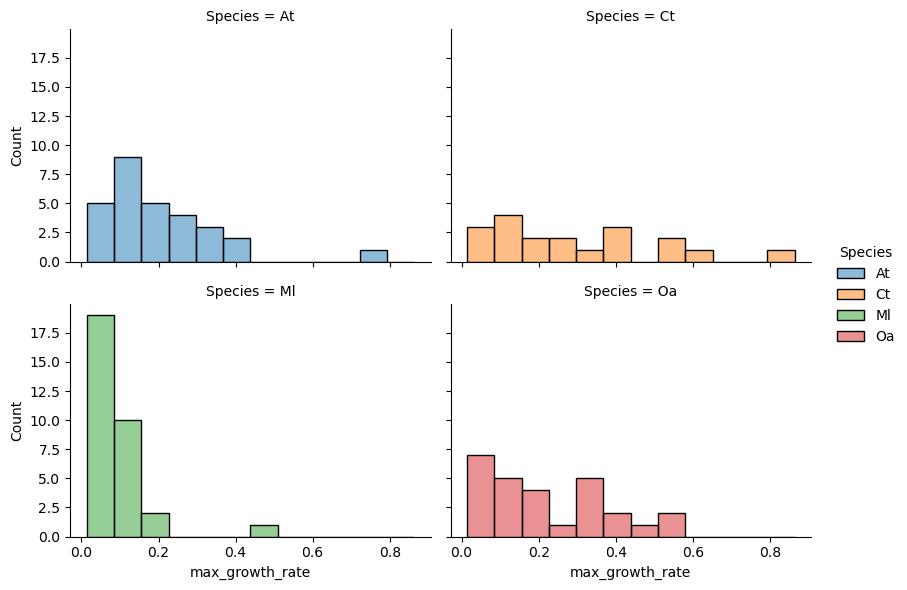

In [ ]:
# mu_matrix
sns.displot(data = res_df, x = 'max_growth_rate', col = 'Species', kde = False, col_wrap=2, hue = 'Species', aspect=1.4, height=3, stat = 'count')# element="step", fill=True, alpha = 0.1
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


In [ ]:
res_df.columns

Index(['Species', 'Carbon source', 'model', 'RSS', 'RMSD', 'bic', 'aic',
       'weighted_bic', 'weighted_aic', 'y0', 'K', 'r', 'nu', 'q0', 'v',
       'has_lag', 'has_nu', 'max_growth_rate', 'min_doubling_time', 'lag',
       'Binary growth evaluation', 'Yield'],
      dtype='object')

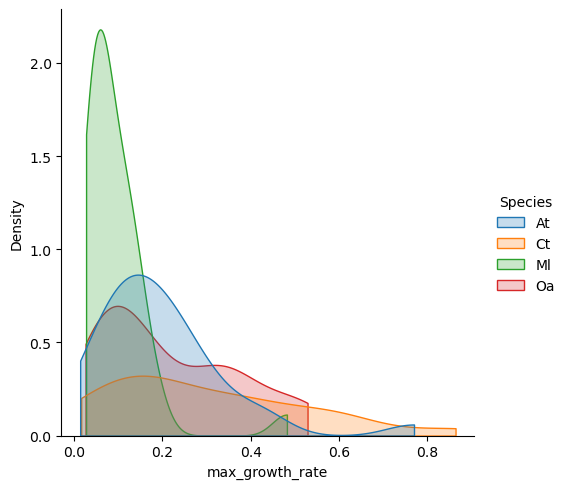

In [ ]:
# mu_matrix
sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', hue = 'Species', kind = 'kde', bw_adjust = 0.8, common_norm = True, fill = True, cut = 0)
# sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', hue = 'Species', kind = 'kde', bw_adjust = 0.8)
# plt.xlim(0, 1.5)
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


In [ ]:
import scipy.stats as stats
data = res_df.loc[res_df['Binary growth evaluation'] == True,'max_growth_rate']
fit_alpha, fit_loc, fit_beta=stats.gamma.fit(data)

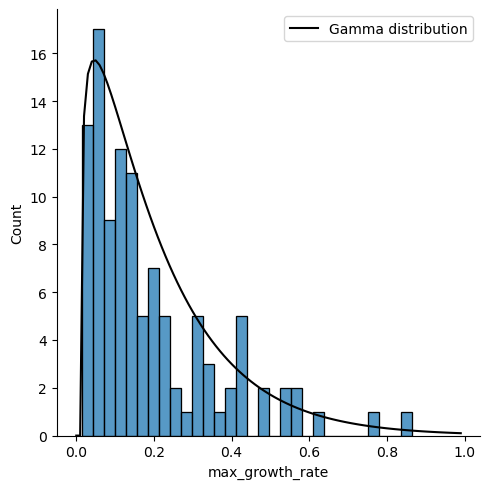

In [ ]:
# mu_matrix
g = sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', kind = 'hist', common_norm = True, fill = True, bins = 30)
# sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', hue = 'Species', kind = 'kde', bw_adjust = 0.8)
# plt.xlim(0, 1.5)
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


x = np.arange(0,1,0.01)
# fit_loc = 0.013
# # fit_beta = 1
fit_alpha = 1.2
y1 = stats.gamma.pdf(x, fit_alpha, fit_loc, fit_beta)
g.ax.plot(x, y1*4, c = 'k', label = 'Gamma distribution')
sns.despine()
plt.legend()

# Fraction of non-utizeable CS

In [ ]:
fraction_ofU = res_df.groupby('Species').agg({'Binary growth evaluation': 'sum'})/32

In [ ]:
max_g = res_df.groupby('Species').agg({'max_growth_rate': ['mean', 'std']})

Text(0, 0.5, 'Max growth rate')

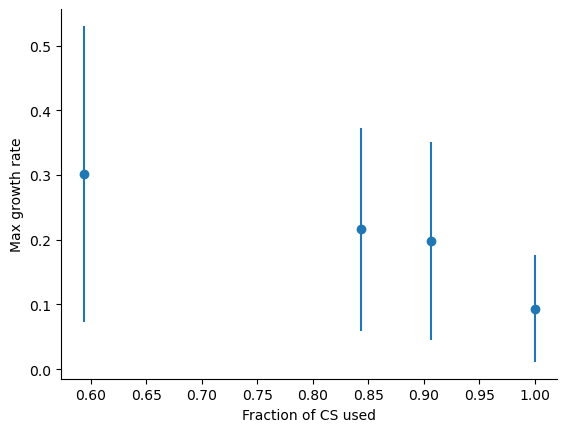

In [ ]:
plt.scatter(fraction_ofU['Binary growth evaluation'], max_g['max_growth_rate']['mean'])#, yerr=max_g['max_growth_rate']['std'], fmt = ''
plt.errorbar(fraction_ofU['Binary growth evaluation'], max_g['max_growth_rate']['mean'], yerr=max_g['max_growth_rate']['std'], fmt='', linestyle='')
sns.despine()
plt.xlabel('Fraction of CS used')
plt.ylabel('Max growth rate')
# l0, = plt.plot(x,y, marker='o', color='b')
# eb = plt.errorbar(x, y, yerr=.1, fmt=None, color='b')

In [ ]:
fit_alpha, fit_loc, fit_beta

(1.2, np.float64(0.01342707603121198), np.float64(0.16446977635199517))

In [ ]:
fit_beta = 0.5